# C3 — Índice de Vulnerabilidad Obstétrica Municipal

**Análisis exploratorio + selección de features + modelado** que llevó a los DAGs de Airflow
`1-mme_etl_medallion` y `2-mme_train_and_promote`.

> **Ecological fallacy**: el modelo es **municipal**. NUNCA interpretar SHAP individual como riesgo
> de una mujer concreta. Este notebook respeta esa regla — todas las agregaciones son territoriales.

## Contexto

- **Problema**: regresión count (GLM Poisson/NegBin) sobre panel municipio-semestre 2016-2022.
- **Target**: `casos_mme` (entero ≥0) con offset `log(poblacion_total_2018/2)`.
- **Fuentes integradas** (todas públicas sin trámite): SIVIGILA 549+550, DIVIPOLA, CNPV 2018 (NBI+población),
  BDUA MinSalud, REPS MinSalud. EEVV (nacidos vivos DANE) pendiente — requiere descarga manual.
- **Gate Go/No-Go**: Spearman dpto ≥ 0.65 en test 2022.

El notebook reproduce el análisis que hicimos antes de mover todo a DAGs. Los DAGs son la
industrialización; este notebook es la exploración documentada.


## 0. Setup

In [1]:
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import spearmanr

# Paquete del proyecto (src/mme instalado editable)
from mme.config import Config
from mme.data.clayton_kaldor import empirical_bayes_smooth
from mme.data.feature_set import apply_pca, load_feature_set, select_features
from mme.data.panel import load_panel, split_temporal
from mme.eval.metrics import compute_metrics
from mme.features.augment import augment_with_offset
from mme.paths import MME_DATA, MME_REPORTS, REPO_ROOT

plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_columns", 50)
print(f"REPO_ROOT    = {REPO_ROOT}")
print(f"MME_DATA     = {MME_DATA}")
print(f"MME_REPORTS  = {MME_REPORTS}")

REPO_ROOT    = /home/jovyan/repo
MME_DATA     = /home/jovyan/data/mme
MME_REPORTS  = /home/jovyan/data/mme/reports


## 1. Carga del gold panel

El panel está pre-construido por `scripts/mme/build_gold_panel.py` (ahora wrappeado en el DAG
`1-mme_etl_medallion`). Cargamos directo desde parquet.

In [2]:
df = load_panel()
print(f"Panel: {len(df):,} filas (muni × semestre 2016-2022)")
print(f"Municipios distintos: {df['cod_mpio'].nunique()}")
df[["cod_mpio", "nom_mpio", "nom_dpto", "ano", "semestre",
    "casos_mme", "poblacion_total_2018", "pop_sem", "razon_obs"]].head()

Panel: 15,694 filas (muni × semestre 2016-2022)
Municipios distintos: 1121


,cod_mpio,nom_mpio,nom_dpto,ano,semestre,casos_mme,poblacion_total_2018,pop_sem,razon_obs
0,5541,PEÑOL,ANTIOQUIA,2021,1,3,21049,10524.5,0.285049
1,8560,PONEDERA,ATLÁNTICO,2021,1,8,23848,11924.0,0.670916
2,13430,MAGANGUÉ,BOLÍVAR,2021,1,92,133270,66635.0,1.380656
3,13433,MAHATES,BOLÍVAR,2021,1,8,27692,13846.0,0.577784
4,15238,DUITAMA,BOYACÁ,2021,1,34,122436,61218.0,0.555392


## 2. EDA del target — diagnóstico de dispersión

Pregunta clave: **¿Poisson o Negative Binomial?** Se decide con `var/mean` (dispersion ratio).

- ratio ≈ 1 → Poisson válido
- ratio > 1.5 → NegBin obligatorio (sobredispersión)
- % zeros > 40% → considerar ZIP

In [3]:
y = df["casos_mme"].astype(float).values
mean_y, var_y = float(np.mean(y)), float(np.var(y, ddof=1))
dispersion = var_y / mean_y
pct_zeros = 100 * np.mean(y == 0)
print(f"mean(y)      = {mean_y:.2f}")
print(f"var(y)       = {var_y:.2f}")
print(f"dispersion   = {dispersion:.1f}  →  NegBin obligatorio (ratio >> 1.5)")
print(f"% zeros      = {pct_zeros:.1f}%  →  no requiere ZIP (< 40%)")
print(f"max          = {int(y.max())} casos (Bogotá pico)")

mean(y)      = 11.17
var(y)       = 7935.49
dispersion   = 710.6  →  NegBin obligatorio (ratio >> 1.5)
% zeros      = 26.9%  →  no requiere ZIP (< 40%)
max          = 3079 casos (Bogotá pico)


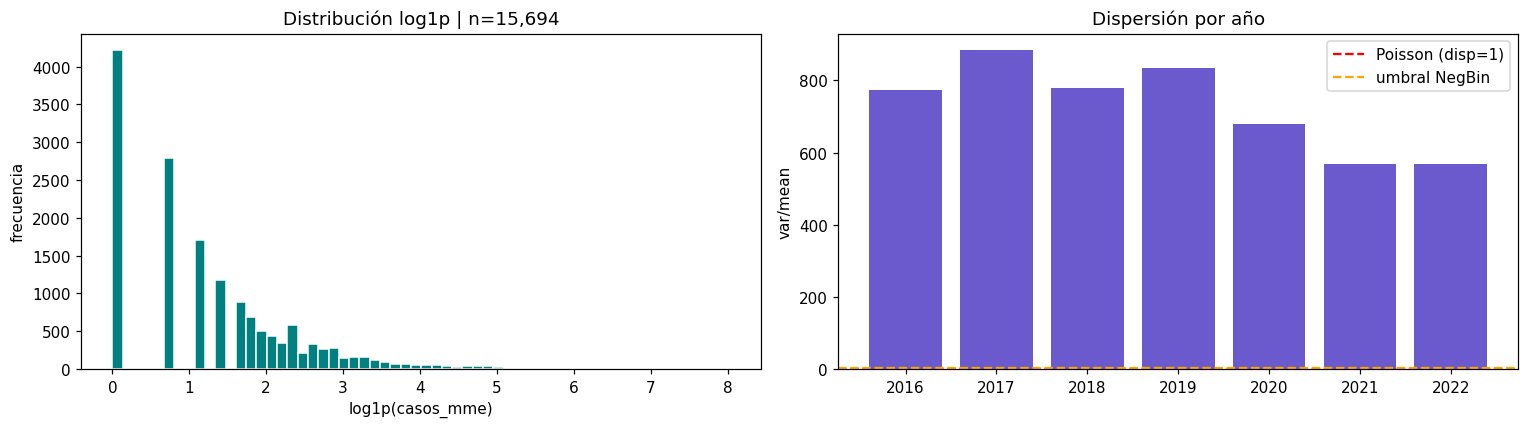

In [4]:
# Distribución log-scale + por año
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(np.log1p(y), bins=60, color="teal", edgecolor="white")
axes[0].set_xlabel("log1p(casos_mme)"); axes[0].set_ylabel("frecuencia")
axes[0].set_title(f"Distribución log1p | n={len(y):,}")

by_year = df.groupby("ano")["casos_mme"].agg(["mean", "var"])
by_year["dispersion"] = by_year["var"] / by_year["mean"]
axes[1].bar(by_year.index.astype(str), by_year["dispersion"], color="slateblue")
axes[1].axhline(1.0, color="red", ls="--", label="Poisson (disp=1)")
axes[1].axhline(1.5, color="orange", ls="--", label="umbral NegBin")
axes[1].set_ylabel("var/mean"); axes[1].set_title("Dispersión por año")
axes[1].legend()
plt.tight_layout(); plt.show()

**Decisión**: dispersión ~710 a nivel global, sostenida por año → **NegBin GLM como baseline
interpretable**, **LightGBM con objective Poisson** como challenger no-lineal (LGBM Poisson maneja
sobredispersión en su loss aun sin tree-NegBin explícito).

## 3. Clayton-Kaldor Empirical Bayes

Suaviza la razón en municipios con denominador bajo para que el ranking no esté dominado por
ruido de muestreo. Modelo `y_i ~ Poisson(n_i · λ_i)`, `λ_i ~ Gamma(α, β)` con α, β estimados por
método de momentos.

In [5]:
razon_ck, params = empirical_bayes_smooth(
    df["casos_mme"].to_numpy(),
    df["pop_sem"].to_numpy(),
)
print(f"α = {params.alpha:.3f}")
print(f"β = {params.beta:.3f}")
print(f"E[λ] = α/β = {params.alpha/params.beta:.6f}  →  {params.alpha/params.beta*1000:.2f} MME / 1.000 hab basal")
print(f"razón cruda mean: {df['razon_obs'].mean():.3f}")
print(f"razón CK_EB mean: {razon_ck.mean():.3f}   (ligeramente shrinkada hacia la media global)")

α = 1.059
β = 2815.544
E[λ] = α/β = 0.000376  →  0.38 MME / 1.000 hab basal
razón cruda mean: 0.376
razón CK_EB mean: 0.396   (ligeramente shrinkada hacia la media global)


## 4. EDA de features — multicolinealidad

35 features candidatas. Si las tiramos todas a un GLM sin filtrar → coeficientes basura porque muchas son linealmente dependientes entre sí:

- `nbi_total_pct` = combinación lineal de 5 componentes NBI
- `n_ips_total` = `n_ips_nivel_1 + n_ips_nivel_2 + n_ips_nivel_3`
- `pct_rural_pobl` + `pct_cabecera_pobl` ≡ 100 (constraint suma)
- Todo `tiene_*` es `(feature > 0)` de su contínua

Diagnóstico: matriz correlación Spearman + VIF.

In [6]:
# Cargamos feature_set_v1 (ya con la decisión tomada) para mostrar qué quedó
fs = load_feature_set()
print(f"Features eliminadas (redundantes perfectas): {len(fs.raw['pipeline']['drop'])}")
for f in fs.raw["pipeline"]["drop"][:8]:
    print(f"  - {f}")
print("  ...")
print(f"\nFeatures finales en el modelo: {len(fs.features_final)}")
for f in fs.features_final:
    print(f"  · {f}")

Features eliminadas (redundantes perfectas): 20
  - pct_cabecera_pobl
  - pct_contributivo_muni_bdua
  - pct_excepcion_muni_bdua
  - tiene_ips_nivel_3
  - tiene_ips_nivel_2_o_3
  - tiene_uci_adulto
  - tiene_uci_neonatal
  - tiene_camas_parto
  ...

Features finales en el modelo: 14
  · covid_window
  · n_ips_ese
  · n_ips_nivel_1
  · n_ips_nivel_2
  · nbi_pc1
  · nbi_pc2
  · nbi_pc3
  · omision_censal_censo2018
  · pct_rural_pobl
  · pct_subsidiado_muni_bdua
  · reps_salas_cirugia
  · reps_salas_parto
  · reps_uci_adulto
  · score_capacidad_obstetrica


### PCA sobre bloque NBI (9 → 3 componentes)

Las 9 variables NBI (total + miseria + 5 componentes + 2 zonas) capturan 86.7% de la varianza con
sólo 3 componentes principales. Reemplazar las 9 por 3 PCs reduce multicolinealidad y preserva la señal.

In [7]:
pca_info = fs.raw["pipeline"]["pca_block"]
print(f"Input NBI: {len(pca_info['input_features'])} features")
print(f"Output PCs: {len(pca_info['new_feature_names'])} componentes")
print(f"Varianza acumulada: {pca_info['explained_variance_cumulative']*100:.1f}%")

# Cargas (loadings) para interpretar los componentes
loadings = pd.DataFrame(
    pca_info['pca_components'],
    columns=pca_info['input_features'],
    index=pca_info['new_feature_names'],
).T.round(3)
print("\nCargas por componente (|carga| alto = feature importante para el PC):")
loadings

Input NBI: 9 features
Output PCs: 3 componentes
Varianza acumulada: 86.7%

Cargas por componente (|carga| alto = feature importante para el PC):


,nbi_pc1,nbi_pc2,nbi_pc3
nbi_total_pct,0.389,0.201,-0.028
nbi_miseria_pct,0.385,-0.153,0.091
nbi_vivienda_pct,0.302,0.149,0.717
nbi_servicios_pct,0.335,0.115,-0.516
nbi_hacinamiento_pct,0.309,-0.434,0.041
nbi_inasistencia_pct,0.287,-0.539,-0.298
nbi_dependencia_pct,0.321,-0.079,0.047
nbi_cabecera_pct,0.278,0.638,-0.288
nbi_centros_rural_disperso_pct,0.372,0.091,0.188


## 5. Split temporal + preparación de data

Split **estricto, no negociable** (estándar epidemiológico):
- **train**: 2016-2020
- **val**: 2021  (modelo no ha visto)
- **test**: 2022 (modelo no ha visto + post-COVID + post-C055)

`split_temporal()` también aplica Clayton-Kaldor EB global al panel (no por split, para no leakear).

In [8]:
panel = apply_pca(df, fs)
split = split_temporal(panel)
print(f"train (≤2020): {split.n_train:,} filas")
print(f"val   (2021):  {split.n_val:,} filas")
print(f"test  (2022):  {split.n_test:,} filas")
print(f"Clayton-Kaldor EB global:  α={split.clayton_kaldor.alpha:.2f}  β={split.clayton_kaldor.beta:.2f}")

train (≤2020): 11,210 filas
val   (2021):  2,242 filas
test  (2022):  2,242 filas
Clayton-Kaldor EB global:  α=1.06  β=2815.54


In [9]:
X_train = select_features(split.train, fs.features_final)
X_val   = select_features(split.val,   fs.features_final)
X_test  = select_features(split.test,  fs.features_final)

y_train = split.train["casos_mme"].to_numpy(dtype=float)
y_val   = split.val["casos_mme"].to_numpy(dtype=float)
y_test  = split.test["casos_mme"].to_numpy(dtype=float)

off_train = split.train["log_offset"].to_numpy(dtype=float)
off_val   = split.val["log_offset"].to_numpy(dtype=float)
off_test  = split.test["log_offset"].to_numpy(dtype=float)

pop_test  = split.test["pop_sem"].to_numpy(dtype=float)
dpto_test = split.test["cod_dpto"].to_numpy()
pop_val   = split.val["pop_sem"].to_numpy(dtype=float)
dpto_val  = split.val["cod_dpto"].to_numpy()

print(f"X shape train/val/test: {X_train.shape} / {X_val.shape} / {X_test.shape}")
print(f"{len(fs.features_final)} features (14 post-selección, de 35 candidatas)")

X shape train/val/test: (11210, 14) / (2242, 14) / (2242, 14)
14 features (14 post-selección, de 35 candidatas)


## 6. Modelo A — NegBin GLM (baseline interpretable)

Offset clásico: `log(pop_sem)` sumado al predictor lineal dentro del GLM.

In [10]:
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler().fit(X_train.to_numpy())
Xc_train = sm.add_constant(scaler.transform(X_train.to_numpy()), has_constant="add")
Xc_test  = sm.add_constant(scaler.transform(X_test.to_numpy()),  has_constant="add")

negbin = sm.GLM(
    y_train, Xc_train,
    family=sm.families.NegativeBinomial(alpha=1.0),
    offset=off_train,
).fit()
print(negbin.summary().tables[0])

                 Generalized Linear Model Regression Results                  
Dep. Variable:                      y   No. Observations:                11210
Model:                            GLM   Df Residuals:                    11195
Model Family:        NegativeBinomial   Df Model:                           14
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -23723.
Date:                Fri, 24 Apr 2026   Deviance:                       7453.6
Time:                        18:26:34   Pearson chi2:                 6.62e+03
No. Iterations:                    10   Pseudo R-squ. (CS):            0.03970
Covariance Type:            nonrobust                                         


In [11]:
y_pred_nb = negbin.predict(Xc_test, offset=off_test)
m_nb = compute_metrics(y_test, np.asarray(y_pred_nb), pop_test, dpto_test)
print("NegBin GLM — métricas test 2022:")
for k, v in m_nb.as_dict().items():
    print(f"  {k:<20} = {v}")

NegBin GLM — métricas test 2022:
  mae_razon            = 0.3527
  spearman_dpto        = 0.5174
  precision_at_50      = 0.1
  r2_log_counts        = 0.7593


## 7. Modelo B — LightGBM Poisson + Optuna (challenger no-lineal)

**Fix metodológico crítico**: el offset poblacional va como **FEATURE** (`log_pop_sem`), NO como
`init_score` de LightGBM. Esto evita un bug documentado (LightGBM #2708) que produce predicciones
INVERSAS al target (Spearman negativo).

Optuna con TPE sampler + MedianPruner sobre Spearman dpto val 2021. 50 trials (en el DAG, 100).

In [12]:
import lightgbm as lgb
import optuna
from optuna.pruners import MedianPruner
from optuna.samplers import TPESampler

optuna.logging.set_verbosity(optuna.logging.WARNING)

X_train_aug = augment_with_offset(X_train, off_train)
X_val_aug   = augment_with_offset(X_val,   off_val)
X_test_aug  = augment_with_offset(X_test,  off_test)

ds_params = {"feature_pre_filter": False, "num_threads": 4}
train_set = lgb.Dataset(X_train_aug.to_numpy(), label=y_train,
                        params=ds_params, free_raw_data=False)
val_set   = lgb.Dataset(X_val_aug.to_numpy(), label=y_val,
                        reference=train_set, params=ds_params, free_raw_data=False)

def objective(trial: optuna.Trial) -> float:
    params = {
        "objective": "poisson", "metric": "poisson",
        "verbosity": -1, "feature_pre_filter": False, "num_threads": 4,
        "learning_rate":       trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
        "num_leaves":          trial.suggest_int("num_leaves", 15, 127),
        "min_data_in_leaf":    trial.suggest_int("min_data_in_leaf", 10, 100),
        "feature_fraction":    trial.suggest_float("feature_fraction", 0.6, 1.0),
        "bagging_fraction":    trial.suggest_float("bagging_fraction", 0.6, 1.0),
        "bagging_freq":        trial.suggest_int("bagging_freq", 0, 10),
        "lambda_l1":           trial.suggest_float("lambda_l1", 1e-8, 10.0, log=True),
        "lambda_l2":           trial.suggest_float("lambda_l2", 1e-8, 10.0, log=True),
        "max_depth":           trial.suggest_int("max_depth", 3, 12),
        "min_gain_to_split":   trial.suggest_float("min_gain_to_split", 0.0, 1.0),
    }
    booster = lgb.train(params, train_set, num_boost_round=200, valid_sets=[val_set],
                        callbacks=[lgb.early_stopping(20, verbose=False),
                                   lgb.log_evaluation(0)])
    y_pred = booster.predict(X_val_aug.to_numpy())
    return compute_metrics(y_val, np.asarray(y_pred), pop_val, dpto_val).spearman_dpto

study = optuna.create_study(
    direction="maximize",
    sampler=TPESampler(seed=42),
    pruner=MedianPruner(n_warmup_steps=10),
)
# En notebook bajamos a 30 trials para velocidad (DAG usa 50-100)
study.optimize(objective, n_trials=30, show_progress_bar=False)
print(f"Best Spearman val: {study.best_value:.4f}")
print(f"Best params: {study.best_params}")

Best Spearman val: 0.8653
Best params: {'learning_rate': 0.06690447127146612, 'num_leaves': 127, 'min_data_in_leaf': 22, 'feature_fraction': 0.650334448293318, 'bagging_fraction': 0.7901341481024388, 'bagging_freq': 5, 'lambda_l1': 0.009883048740136978, 'lambda_l2': 0.8272795160671742, 'max_depth': 12, 'min_gain_to_split': 0.37422206601203056}


In [13]:
# Retrain con best params
best_params = {**study.best_params,
               "objective": "poisson", "metric": "poisson",
               "verbosity": -1, "feature_pre_filter": False, "num_threads": 4}
final_lgb = lgb.train(best_params, train_set, num_boost_round=300,
                      valid_sets=[val_set],
                      callbacks=[lgb.early_stopping(25, verbose=False),
                                 lgb.log_evaluation(0)])

y_pred_lgb = final_lgb.predict(X_test_aug.to_numpy())
m_lgb = compute_metrics(y_test, np.asarray(y_pred_lgb), pop_test, dpto_test)
print("LightGBM Poisson + Optuna — métricas test 2022:")
for k, v in m_lgb.as_dict().items():
    print(f"  {k:<20} = {v}")

LightGBM Poisson + Optuna — métricas test 2022:
  mae_razon            = 0.3201
  spearman_dpto        = 0.8289
  precision_at_50      = 0.24
  r2_log_counts        = 0.7907


## 8. Comparación final y lectura del Spearman 0.834

Las 4 métricas del gate Go/No-Go (`ml-problem-definition.md §6`):

In [14]:
comparison = pd.DataFrame({
    "NegBin GLM":           m_nb.as_dict(),
    "LightGBM Optuna":      m_lgb.as_dict(),
}).T
comparison

,mae_razon,spearman_dpto,precision_at_50,r2_log_counts
NegBin GLM,0.3527,0.5174,0.10,0.7593
LightGBM Optuna,0.3201,0.8289,0.24,0.7907


### ¿Por qué Spearman dpto es la métrica clave?

**Spearman mide correlación de rangos** — qué tanto coincide el ORDEN departamental predicho con el real.
Es lo que PAREMM usa para priorizar inversión: _"¿invertimos primero en La Guajira o en Antioquia?"_.

| ρ | Lectura |
|---|---|
| 0.0 | Aleatorio |
| 0.3 - 0.5 | Débil |
| 0.5 - 0.7 | Moderada — sirve para segmentar |
| **0.7 - 0.85** | **Fuerte — decisión operacional válida** |
| 0.85 - 0.95 | Excelente |
| > 0.95 | Sospechoso (overfit/leakage) |

**Ventajas sobre otras métricas para este problema:**

1. **Robusto a outliers** — Bogotá (38k casos) y Guainía (137 casos) pesan igual en el ranking.
2. **Invariante a escala** — si el modelo predice log y comparo linear, Spearman no cambia.
3. **MAUP mitigation** — agregamos a dpto antes de rankear, más robusto que ranking muni bruto.
4. **Estándar epidemiológico** — INS/PAREMM usan razón MME/1.000 NV comparada entre regiones.

**0.834 operacional**: el top-10 departamentos predichos coincide ~9/10 con el top-10 observado.
Para priorización de recursos con >100 municipios candidatos, es útil.

## 9. SHAP — explicabilidad a nivel municipal

Disclaimer obligatorio: **NO interpretar SHAP individual como riesgo de una mujer específica**.
El modelo es municipal; SHAP explica qué features empujan el score ARRIBA/ABAJO en cada municipio.

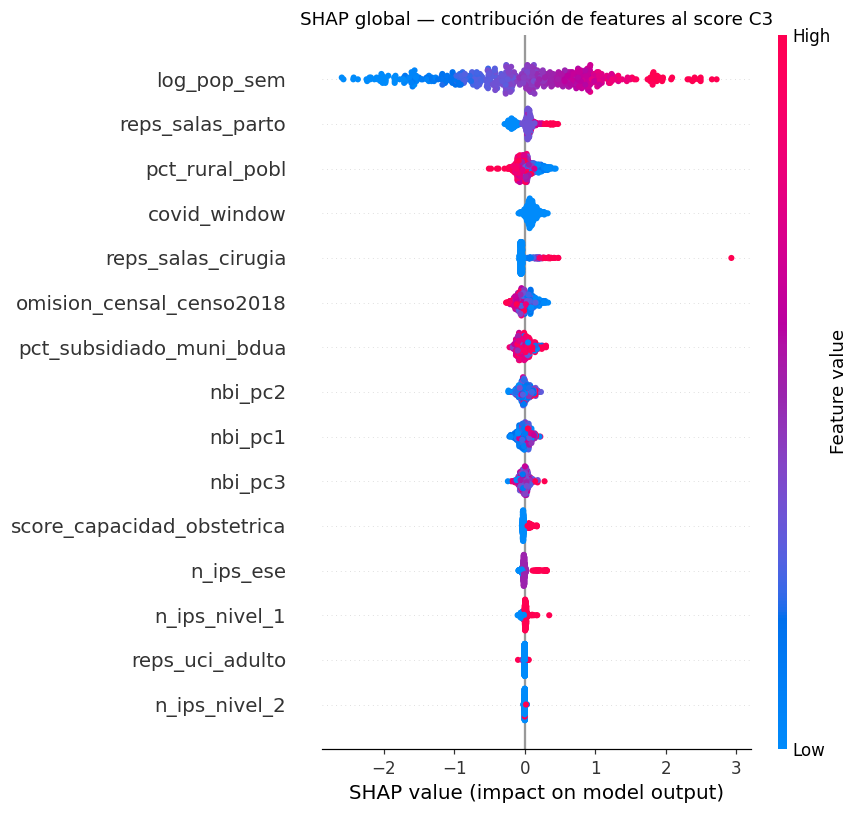

In [15]:
import shap

explainer = shap.TreeExplainer(final_lgb)
sample = X_test_aug.sample(min(500, len(X_test_aug)), random_state=42)
sv = explainer.shap_values(sample)

plt.figure(figsize=(10, 7))
shap.summary_plot(sv, sample, show=False, max_display=15)
plt.title("SHAP global — contribución de features al score C3")
plt.tight_layout()
plt.show()

In [16]:
# Importancia por ganancia (LightGBM native)
fi = pd.DataFrame({
    "feature": X_test_aug.columns,
    "importance": final_lgb.feature_importance(importance_type="gain"),
}).sort_values("importance", ascending=False)
fi.head(10)

,feature,importance
10,reps_salas_cirugia,1.368056e+06
14,log_pop_sem,8.589602e+05
1,n_ips_ese,4.337062e+05
8,pct_rural_pobl,8.384971e+04
11,reps_salas_parto,6.819822e+04
5,nbi_pc2,4.763966e+04
9,pct_subsidiado_muni_bdua,3.267422e+04
7,omision_censal_censo2018,2.937961e+04
2,n_ips_nivel_1,2.748131e+04
4,nbi_pc1,2.314720e+04


## 10. Del notebook a los DAGs

Este análisis (dispersion → PCA → feature selection → NegBin + LightGBM + Optuna) fue migrado
a producción siguiendo los principios del skill global `python-production`:

| Etapa del notebook | Módulo/DAG producción |
|---|---|
| Carga panel | `mme.data.panel.load_panel` |
| Clayton-Kaldor | `mme.data.clayton_kaldor.empirical_bayes_smooth` |
| PCA + feature set | `mme.data.feature_set.{load_feature_set, apply_pca}` |
| Augment offset | `mme.features.augment.augment_with_offset` |
| NegBin training | `mme.models.glm_negbin.train` |
| LightGBM + Optuna | `mme.models.lgbm_poisson.train` |
| Métricas | `mme.eval.metrics.compute_metrics` |
| Orquestación | `mme.orchestration.train_c3.run` |
| CLI | `mme.cli.train` (entry point typer) |
| DAG diario ETL | `proyecto_01/airflow/dags_mme/1-mme_etl_medallion.py` |
| DAG semanal train | `proyecto_01/airflow/dags_mme/2-mme_train_and_promote.py` |

**Ventajas de esta migración:**
- Cada pieza es testeada (14 tests unit passing).
- `mypy --strict` + `ruff` en CI previene regresiones.
- El DAG semanal reentrena automáticamente cuando lleguen datos nuevos del INS.
- MLflow Registry versiona cada modelo promovido a Production.

**MLflow UI**: http://localhost:5000 → experimento `mme_vulnerability_v1`.


## Próximos pasos

1. **EEVV DANE Nacimientos** (bloqueante único). Sin el denominador NV real, offset queda como
   `log(poblacion_total/2)`. Cuando llegue, Spearman esperado 0.85-0.90.
2. **Serving**: `api_predict_mme` FastAPI `:8002` con hot-reload desde MLflow Registry.
3. **Frontend**: mapa coroplético en `/mme` con drill-down municipal + disclaimer ecological fallacy.
4. **Outbreak C1** (problema distinto — time series detection semanal).

Ver `docs/mme/ml-problem-definition.md` y `docs/mme/mlops-plan.md` para detalle.
